In [ ]:
import re
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
from torch.utils.data import Dataset, DataLoader, TensorDataset

import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch versão {torch.__version__} importado com sucesso!")

# Definindo o dispositivo (Usa GPU se disponível, senão CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de processamento: {device}")

torch.manual_seed(42)
np.random.seed(42)

PyTorch versão 2.11.0+cu126 importado com sucesso!
Dispositivo de processamento: cuda


In [4]:
# ATENÇÃO: Substitua 'spam.csv' pelo caminho correto do seu arquivo caso necessário.
# O encoding 'latin-1' é padrão para esse dataset original.
df = pd.read_csv('spam.csv', encoding='latin-1')

# Mantendo apenas as colunas úteis e renomeando para facilitar
df = df[['v1','v2']]
df.columns = ['label', 'text']

# Convertendo rótulos para números: ham = 0, spam = 1
df['label']= df['label'].map({'ham': 0, 'spam': 1})

print("Exemplo dos dados:")
display(df.head())

# Configurações do modelo e tokenização
MAX_SEQ_LENGTH = 20     # Analisaremos até 20 palavras por mensagem
VOCAB_SIZE = 3000       # Tamanho máximo do nosso dicionário
EMBED_SIZE = 32         # Tamanho dos vetores de atenção

print(f"\n Total de mensagens no dataset: {len(df)}")


Exemplo dos dados:


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."



 Total de mensagens no dataset: 5572


In [7]:
# Limpeza básica e separação de palavras
df['tokens']= df['text'].apply(lambda x: str(x).lower().split()[:MAX_SEQ_LENGTH])

# Construindo o vocabulário (mapeamento de palavra -> número)
all_words = [word for tokens in df['tokens'] for word in tokens]
word_counts = Counter(all_words)
common_words = [word for word, count in word_counts.most_common (VOCAB_SIZE - 2)]

# Dicionários de conversão
word2idx = {word: idx + 2 for idx, word in enumerate(common_words)}
word2idx['<PAD>'] = 0 # Preenchimento para mensagens curtas
word2idx['<UNK>'] = 1 # Palavras desconhecidas
idx2word = {idx: word for word, idx in word2idx.items()}

def encode_tokens(tokens) :
    encoded = [word2idx.get(word, word2idx['<UNK>']) for word in tokens]
    # Preenche com zeros (PAD) até o tamanho máximo
    if len(encoded) < MAX_SEQ_LENGTH:
        encoded += [word2idx['<PAD>']] * (MAX_SEQ_LENGTH - len(encoded))
    return encoded

# Convertendo os textos em matrizes de numeros
X = torch.tensor([encode_tokens(tokens) for tokens in df['tokens']], dtype=torch.long)
y = torch.tensor(df['label'].values, dtype=torch.long)

# Criando o DataLoader para o PyTorch
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [9]:
class PedagocicalSelfAttention(nn.Module):
    def __init__(self, embed_size):
        super(PedagocicalSelfAttention, self).__init__()
        self.embed_size = embed_size

        # Uma única "cabeça" de atenção para facilitar o plot da matriz no final
        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.keys = nn.Linear(embed_size, embed_size, bias=False)
        self.queries = nn.Linear(embed_size, embed_size, bias=False)

    def forward(self, x):
        Q = self.queries(x)
        K = self.keys(x)
        V = self.values (x)

        # Dot Product (Q * K^T)
        score = torch.bmm(Q, K.transpose(1, 2))
        score = score / math.sqrt(self.embed_size)
        
        # Extração dos pesos (Softmax)
        attention_weights = F.softmax(score, dim=-1)
        
        # Matriz final (Pesos * V)
        out = torch.bmm(attention_weights, V)

        return out, attention_weights

In [12]:
class TransformerSpamClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size, max_length):
        super(TransformerSpamClassifier, self).__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.position_embedding = nn.Embedding(max_length, embed_size)

        self.attention = PedagocicalSelfAttention(embed_size)

        # Camada final para decidir: 0 (Ham) ou 1 (Spam)
        self.fc = nn.Linear(embed_size, 2)

    def forward(self, x):
        N, seq_length = x.shape
        positions = torch.arange(0, seq_length).expand(N, seq_length).to(x.device)

        # Soma dos Embeddings (Significado + Posição)
        out = self.token_embedding(x) + self.position_embedding(positions)
        
        out, attn_weights = self.attention(out)
        
        # Global Average Pooling: tira a média da sequência inteira
        pooled = out.mean(dim=1)

        # Previsão final
        logits = self.fc(pooled)

        return logits, attn_weights

In [14]:
model = TransformerSpamClassifier(VOCAB_SIZE, EMBED_SIZE, MAX_SEQ_LENGTH).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 100 # Em dados reais, poucas épocas já convergem bem

print("Iniciando o treinamento ... ")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        logits, _ = model(batch_X)

        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Calculando acurácia do batch
        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    acc = 100. * correct / total

    print(f"Época [{epoch+1}/{EPOCHS}] | Loss: {total_loss/len(dataloader):.4f} | Acurácia: {acc:.2f}%")
    


Iniciando o treinamento ... 
Época [1/100] | Loss: 0.4360 | Acurácia: 83.26%
Época [2/100] | Loss: 0.2837 | Acurácia: 88.59%
Época [3/100] | Loss: 0.1880 | Acurácia: 93.13%
Época [4/100] | Loss: 0.1385 | Acurácia: 95.33%
Época [5/100] | Loss: 0.1098 | Acurácia: 96.55%
Época [6/100] | Loss: 0.0873 | Acurácia: 97.34%
Época [7/100] | Loss: 0.0730 | Acurácia: 97.85%
Época [8/100] | Loss: 0.0597 | Acurácia: 98.26%
Época [9/100] | Loss: 0.0482 | Acurácia: 98.82%
Época [10/100] | Loss: 0.0416 | Acurácia: 98.96%
Época [11/100] | Loss: 0.0329 | Acurácia: 99.21%
Época [12/100] | Loss: 0.0279 | Acurácia: 99.23%
Época [13/100] | Loss: 0.0233 | Acurácia: 99.43%
Época [14/100] | Loss: 0.0198 | Acurácia: 99.50%
Época [15/100] | Loss: 0.0169 | Acurácia: 99.59%
Época [16/100] | Loss: 0.0135 | Acurácia: 99.71%
Época [17/100] | Loss: 0.0110 | Acurácia: 99.71%
Época [18/100] | Loss: 0.0090 | Acurácia: 99.77%
Época [19/100] | Loss: 0.0072 | Acurácia: 99.82%
Época [20/100] | Loss: 0.0069 | Acurácia: 99.86%



Mensagem: 'URGENT You won a FREE prize ring this number to claim money'
Previsão do Modelo: SPAM (Confiança: 88.20%)



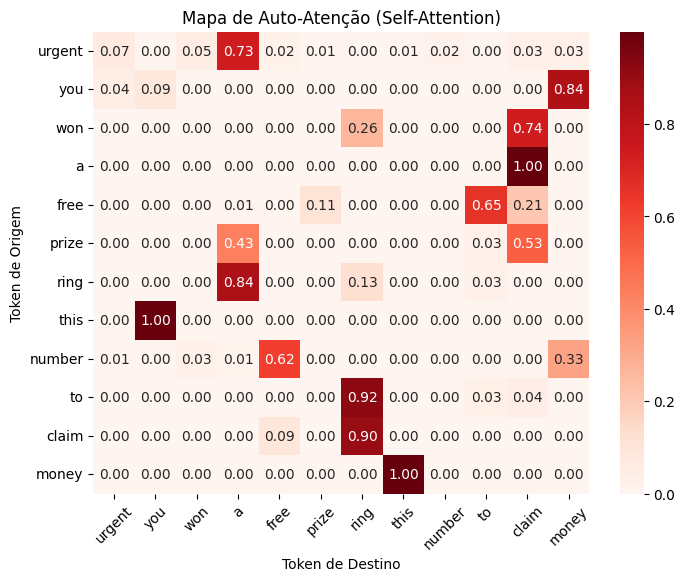


Mensagem: 'hey man are we still going to the game tomorrow'
Previsão do Modelo: HAM (Normal) (Confiança: 100.00%)



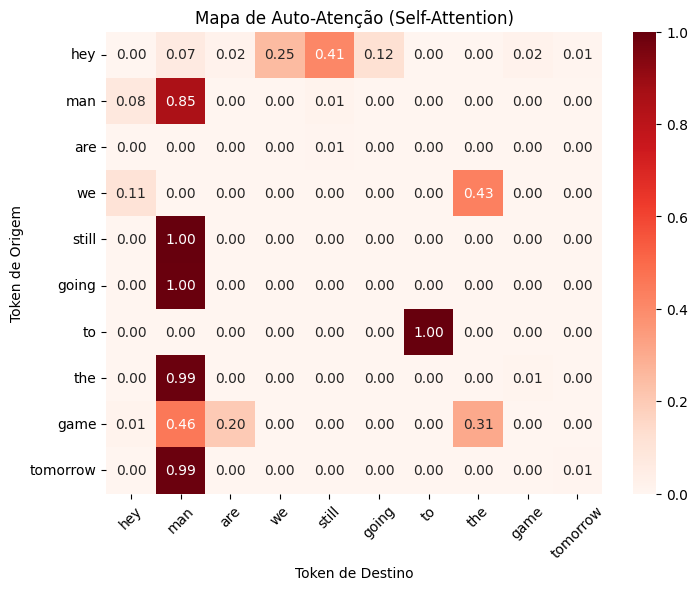

In [15]:
def explain_prediction(text, model):
    model.eval()

    # Preparar e limpar a frase
    tokens = text.lower().split()[:MAX_SEQ_LENGTH]
    encoded = encode_tokens(tokens)
    input_tensor = torch.tensor([encoded], dtype=torch.long).to(device)

    # Recuperar os tokens reais em texto (ignorando PAD para o plot ficar limpo)
    real_tokens = [idx2word[idx] for idx in encoded if idx != 0]
    seq_len = len(real_tokens)

    with torch.no_grad():
        logits, attention = model(input_tensor)
        pred_class = torch.argmax(logits, dim=1).item()
        confidence = F.softmax(logits, dim=1)[0][pred_class].item()

    # Cortar a matriz de atenção apenas para o tamanho das palavras reais (sem PAD)
    # attention shape: (Batch, Seq, Seq)
    attn_matrix = attention[0, :seq_len, :seq_len].cpu().numpy()

    class_name = "SPAM" if pred_class == 1 else "HAM (Normal)"
    print(f"\nMensagem: '{text}'")
    print(f"Previsão do Modelo: {class_name} (Confiança: {confidence*100:.2f}%)\n")

    # Plotando o Heatmap
    plt.figure(figsize=(8,6))
    sns.heatmap(attn_matrix, annot=True, cmap='Reds', fmt=".2f",
                xticklabels=real_tokens, yticklabels=real_tokens)
    plt.title("Mapa de Auto-Atenção (Self-Attention)")
    plt.xlabel("Token de Destino")
    plt.ylabel("Token de Origem")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()
    
# Teste com um Spam típico
teste_spam = "URGENT You won a FREE prize ring this number to claim money"
explain_prediction(teste_spam, model)

# Teste com uma mensagem normal
teste_ham = "hey man are we still going to the game tomorrow"
explain_prediction(teste_ham, model)